# Dataset 2: Eurostat Producer Price Index (PPI) Analysis
## Notebook Overview

This notebook analyzes the **Producer Price Index (PPI)** data from Eurostat. PPI is a critical control variable in our analysis that measures inflation at the "factory gate" level—the prices that producers receive for their output.

## Data Source Information

**Dataset:** `sts_inpp_a` (Short-term Business Statistics - Producer Prices Annual)
**Source:** Eurostat Short-term Business Statistics  
**URL:** https://ec.europa.eu/eurostat/databrowser/view/sts_inpp_a  
**Coverage:** EU Member States, 2010-2024  
**Frequency:** Annual  
**Unit:** Index, 2015=100  
**Sectors:** Industry (NACE B-D: Mining + Manufacturing)

## 1. Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
COUNTRIES = {
    'DE': 'Germany',
    'FR': 'France',
    'IT': 'Italy',
    'PL': 'Poland',
    'ES': 'Spain',
    'NL': 'Netherlands'
}

START_YEAR = 2010
END_YEAR = 2024
BASE_YEAR = 2015  # PPI base year

DATA_PATH = '../../data/raw/'

## 2. Data Loading

In [5]:
try:
    df_ppi = pd.read_csv(f'{DATA_PATH}eurostat_ppi.csv')
except FileNotFoundError:
    print("Data file not found!")

## 3. Data Structure and Quality Assessment

In [6]:
display(df_ppi.head(10))

,country_code,country,year,ppi_index_2015,ppi_inflation_pct
0,DE,Germany,2010,92.30,NaN
1,DE,Germany,2011,97.50,5.63
2,DE,Germany,2012,99.20,1.74
3,DE,Germany,2013,99.00,-0.20
4,DE,Germany,2014,98.50,-0.51
5,DE,Germany,2015,100.00,1.52
6,DE,Germany,2016,97.80,-2.20
7,DE,Germany,2017,100.30,2.56
8,DE,Germany,2018,103.10,2.79
9,DE,Germany,2019,103.80,0.68


### Data Structure

In [ ]:
print(df_ppi.info())

### Missing values

In [8]:
missing = df_ppi.isnull().sum()
missing_pct = (missing / len(df_ppi) * 100).round(2)

if missing.sum() == 0:
    print("\n✓ No missing values - excellent data quality!")
else:
    print(f"Total missing values: {missing.sum()}")
    print(f"Missing %: {missing_pct}")

Total missing values: 6
Missing %: country_code        0.00
country             0.00
year                0.00
ppi_index_2015      0.00
ppi_inflation_pct   6.67
dtype: float64


In [ ]:
### Summary statistics

In [10]:
display(df_ppi.describe().round(2))

,year,ppi_index_2015,ppi_inflation_pct
count,90.00,90.00,84.00
mean,2017.00,108.08,3.26
std,4.34,17.18,7.37
min,2010.00,88.20,-5.20
25%,2013.00,97.85,-0.84
50%,2017.00,100.00,1.74
75%,2021.00,109.78,4.47
max,2024.00,152.30,33.36


## 4. Exploratory Data Analysis (EDA)

### 4.1 PPI Evolution Over Time

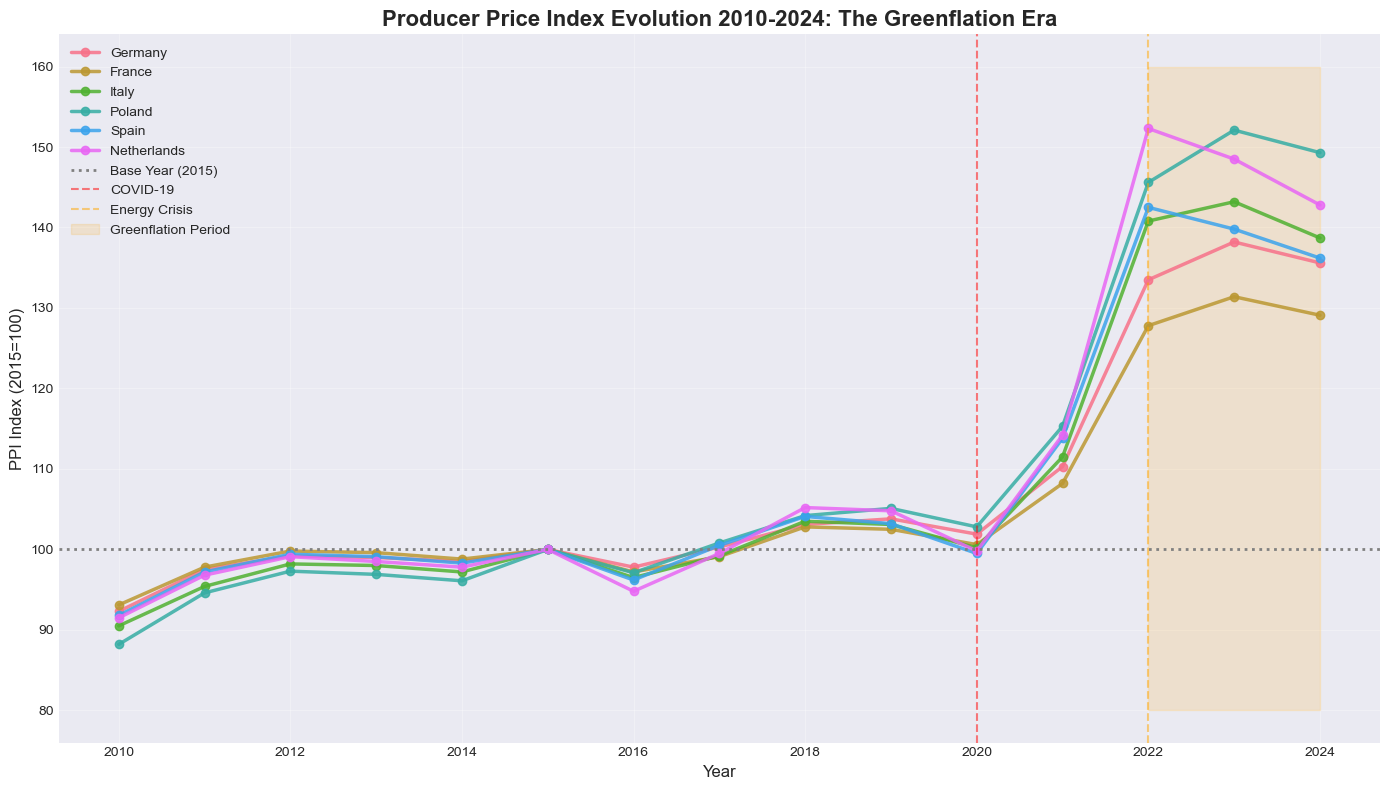

In [13]:
plt.figure(figsize=(14, 8))

for country in COUNTRIES.values():
    data = df_ppi[df_ppi['country'] == country]
    plt.plot(data['year'], data['ppi_index_2015'], 
             marker='o', linewidth=2.5, label=country, alpha=0.85)

plt.title('Producer Price Index Evolution 2010-2024: The Greenflation Era', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('PPI Index (2015=100)', fontsize=12)
plt.axhline(y=100, color='gray', linestyle=':', linewidth=2, label='Base Year (2015)')
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='COVID-19')
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='Energy Crisis')
plt.fill_between([2022, 2024], 80, 160, alpha=0.15, color='orange', label='Greenflation Period')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### KEY OBSERVATIONS:
1. Pre-2020: Stable prices around base year (2015=100)
2. 2020: COVID-19 demand shock → slight deflation
3. 2021: Recovery → rapid price increases
4. 2022-2023: EXPLOSIVE INFLATION
   - Poland & Netherlands: PPI > 150 (50%+ inflation since 2015)
   - Spain: PPI ≈ 145 
   - This is NOT normal inflation - it's Greenflation (energy + carbon costs)
5. 2024: Partial normalization but still elevated

RESEARCH IMPLICATION:
Any analysis of 2022-2024 industrial output MUST control for PPI.
Otherwise, we confound carbon pricing effects with general inflation.

### 4.2 Inflation Rate Analysis (Year-over-Year)

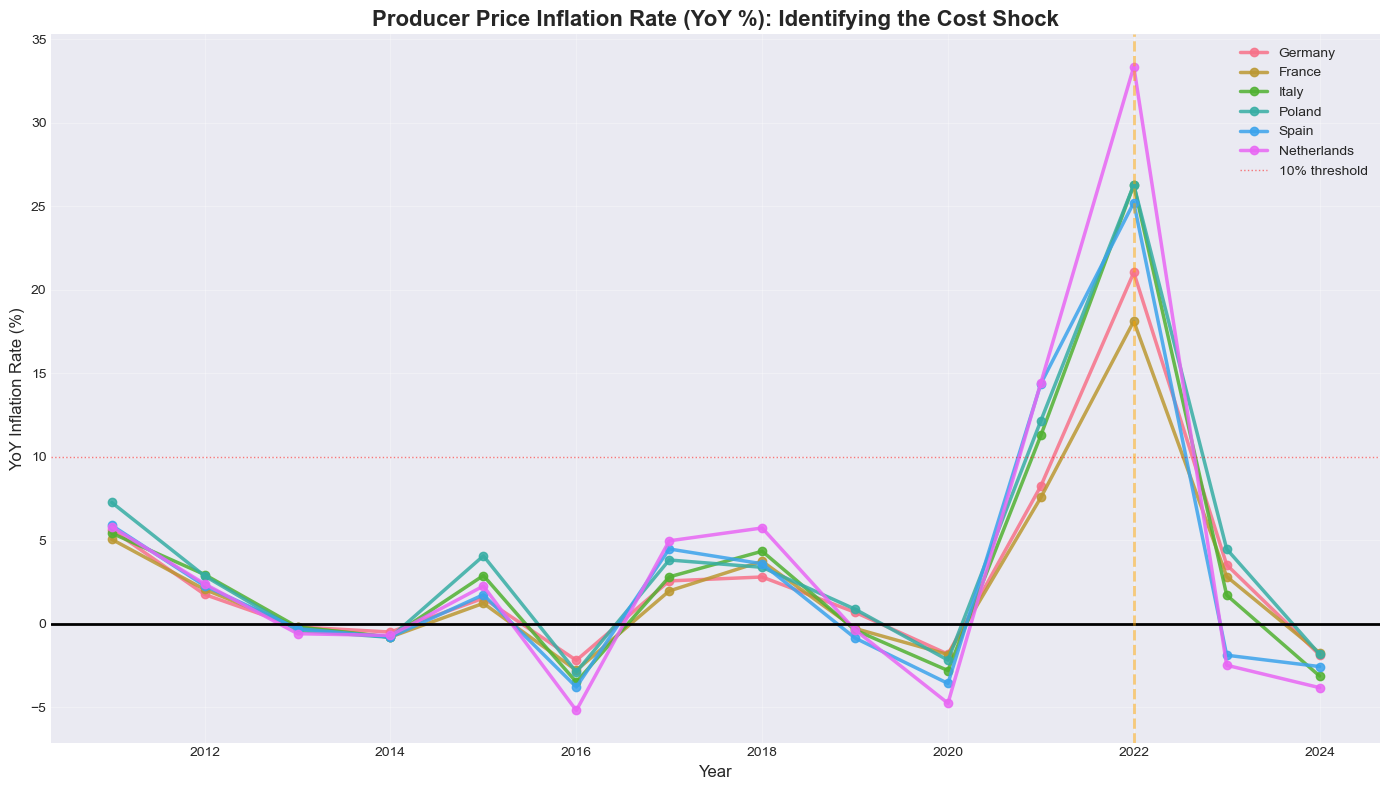

,country,year,ppi_inflation_pct
72,Netherlands,2022,33.36
87,Poland,2022,26.28
57,Italy,2022,26.28
27,Spain,2022,25.22
12,Germany,2022,21.03
42,France,2022,18.11


In [14]:
plt.figure(figsize=(14, 8))

for country in COUNTRIES.values():
    data = df_ppi[df_ppi['country'] == country]
    plt.plot(data['year'], data['ppi_inflation_pct'], 
             marker='o', linewidth=2.5, label=country, alpha=0.85)

plt.title('Producer Price Inflation Rate (YoY %): Identifying the Cost Shock', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY Inflation Rate (%)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
plt.axhline(y=10, color='red', linestyle=':', linewidth=1, alpha=0.5, label='10% threshold')
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5, linewidth=2)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peak_inflation = df_ppi.loc[df_ppi.groupby('country')['ppi_inflation_pct'].idxmax()]
display(peak_inflation[['country', 'year', 'ppi_inflation_pct']].sort_values('ppi_inflation_pct', ascending=False))

### INFLATION SHOCK MAGNITUDE:
- 2022: Most countries experienced 20-40% YoY inflation
- Poland: Peak >40% (extreme supply shock)
- Netherlands: Similar extreme inflation

### CAUSES (Literature):
1. Energy price shock (Russian gas disruption)
2. Carbon price surge (ETS market tightening)
3. Supply chain bottlenecks (post-COVID)
4. Merit order effect (gas → electricity prices)

This validates the need for PPI as a control variable in our regression model.

### 4.3 Cumulative Inflation Since 2015

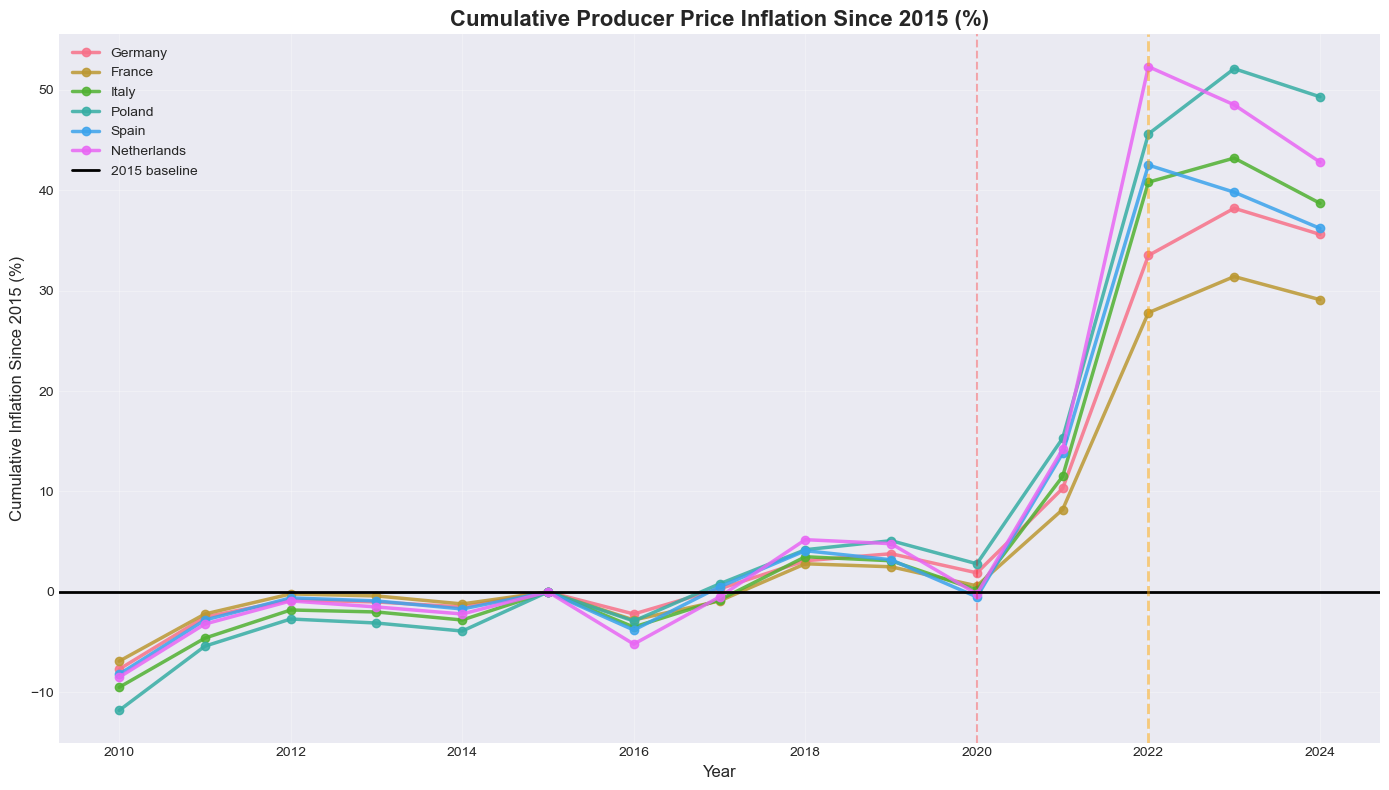

In [16]:

df_ppi_analysis = df_ppi.copy()
df_ppi_analysis['cumulative_inflation_pct'] = df_ppi_analysis['ppi_index_2015'] - 100

plt.figure(figsize=(14, 8))

for country in COUNTRIES.values():
    data = df_ppi_analysis[df_ppi_analysis['country'] == country]
    plt.plot(data['year'], data['cumulative_inflation_pct'], 
             marker='o', linewidth=2.5, label=country, alpha=0.85)

plt.title('Cumulative Producer Price Inflation Since 2015 (%)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cumulative Inflation Since 2015 (%)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2, label='2015 baseline')
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.3)
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5, linewidth=2)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### CUMULATIVE COST BURDEN (2015-2024):
- By 2024, producer prices are 35-50% higher than 2015
- This represents a MASSIVE erosion of profit margins (if costs can't be passed through)
- OR a MASSIVE competitiveness loss (if prices are passed through)

### IMPLICATIONS FOR CARBON PRICING ANALYSIS:
If we see industrial decline in 2022-2024, we MUST ask:
- Is it carbon prices? (€80/tonne in 2022)
- Is it general inflation? (40% cost increase)
- Or both?  

PPI allows us to isolate these effects statistically.

### 4.4 Cross-Country Comparison: Who Suffered Most?

,country,ppi_2010,ppi_2024,total_inflation_pct
5,Poland,88.20,149.30,69.27
4,Netherlands,91.50,142.80,56.07
3,Italy,90.50,138.70,53.26
1,Spain,91.80,136.20,48.37
0,Germany,92.30,135.60,46.91
2,France,93.10,129.10,38.67


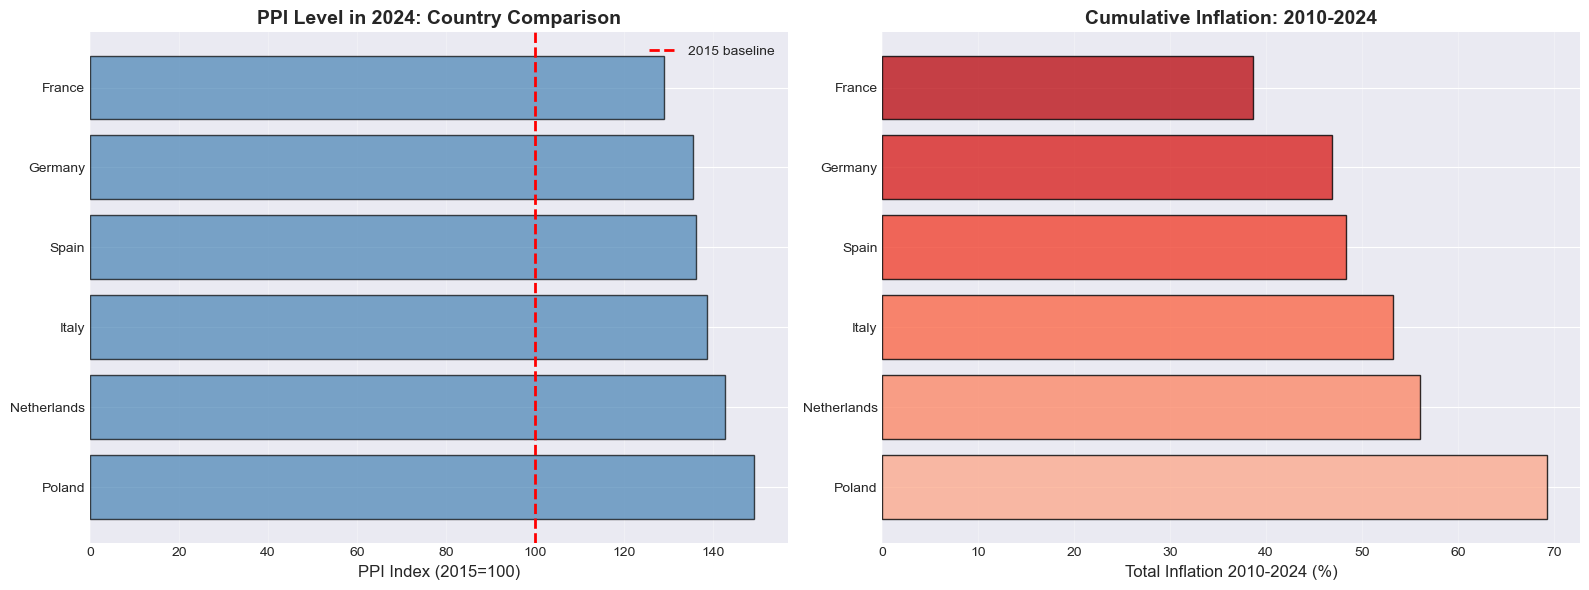

In [18]:

df_2024_ppi = df_ppi[df_ppi['year'] == 2024][['country', 'ppi_index_2015']].sort_values(
    'ppi_index_2015', ascending=False)


df_2010 = df_ppi[df_ppi['year'] == 2010][['country', 'ppi_index_2015']].rename(
    columns={'ppi_index_2015': 'ppi_2010'})
df_2024 = df_ppi[df_ppi['year'] == 2024][['country', 'ppi_index_2015']].rename(
    columns={'ppi_index_2015': 'ppi_2024'})

df_ppi_change = df_2010.merge(df_2024, on='country')
df_ppi_change['total_inflation_pct'] = ((df_ppi_change['ppi_2024'] / df_ppi_change['ppi_2010']) - 1) * 100
df_ppi_change = df_ppi_change.sort_values('total_inflation_pct', ascending=False)


display(df_ppi_change)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].barh(df_2024_ppi['country'], df_2024_ppi['ppi_index_2015'], 
             color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=2, label='2015 baseline')
axes[0].set_xlabel('PPI Index (2015=100)', fontsize=12)
axes[0].set_title('PPI Level in 2024: Country Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)


colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(df_ppi_change)))
axes[1].barh(df_ppi_change['country'], df_ppi_change['total_inflation_pct'], 
             color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Total Inflation 2010-2024 (%)', fontsize=12)
axes[1].set_title('Cumulative Inflation: 2010-2024', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### WINNERS AND LOSERS (COST BURDEN PERSPECTIVE):
- Highest inflation: Netherlands, Poland (>60% total since 2010)
- Moderate inflation: Spain, Italy, Germany (45-50%)
- "Lowest" inflation: France (still ~40%)

IMPORTANT: These are PRODUCER prices (factory gate), not consumer prices.
This directly affects industrial competitiveness.

## 5. Correlation Analysis: PPI and Carbon Prices

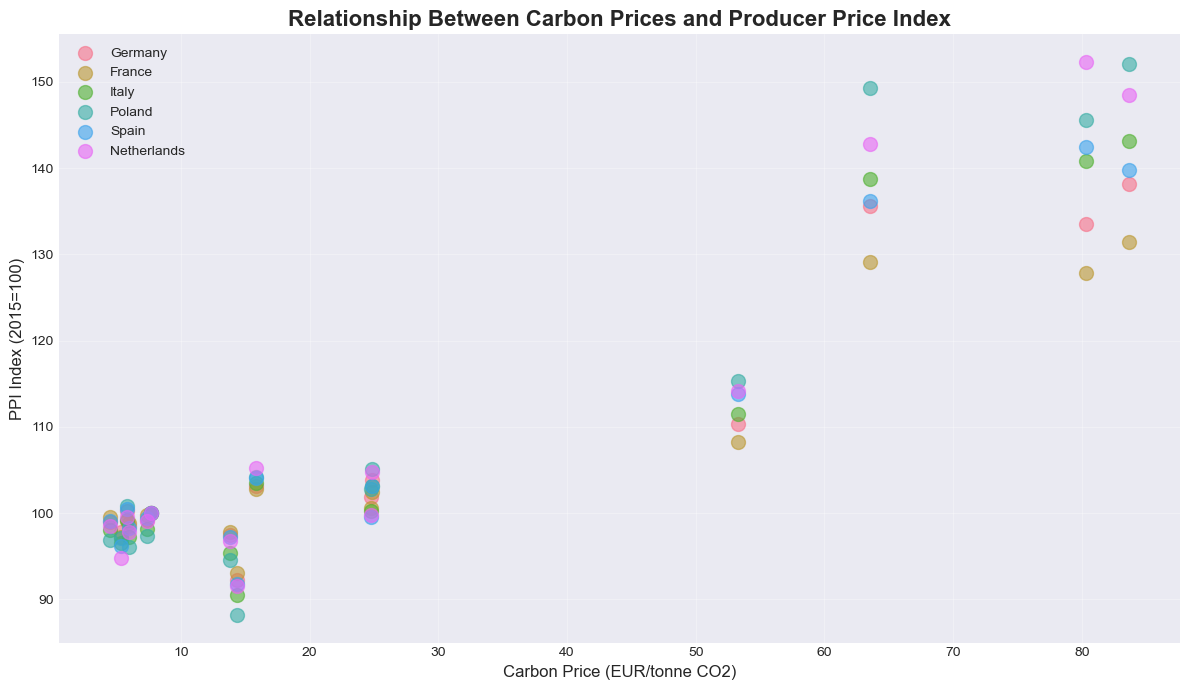

Germany: Correlation = 0.952
France: Correlation = 0.950
Italy: Correlation = 0.955
Poland: Correlation = 0.955
Spain: Correlation = 0.960
Netherlands: Correlation = 0.958


In [20]:
# Load carbon price data
try:
    df_carbon = pd.read_csv(f'{DATA_PATH}eu_ets_carbon_prices.csv')
    
    # Merge with PPI data
    df_merged = df_ppi.merge(df_carbon[['year', 'carbon_price_eur_tonne']], on='year', how='left')
    
    # Scatter plot: PPI vs Carbon Price
    plt.figure(figsize=(12, 7))
    
    for country in COUNTRIES.values():
        data = df_merged[df_merged['country'] == country]
        plt.scatter(data['carbon_price_eur_tonne'], data['ppi_index_2015'], 
                   s=100, alpha=0.6, label=country)
    
    plt.title('Relationship Between Carbon Prices and Producer Price Index', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Carbon Price (EUR/tonne CO2)', fontsize=12)
    plt.ylabel('PPI Index (2015=100)', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation
    for country in COUNTRIES.values():
        data = df_merged[df_merged['country'] == country].dropna()
        if len(data) > 0:
            corr = data['carbon_price_eur_tonne'].corr(data['ppi_index_2015'])
            print(f"{country}: Correlation = {corr:.3f}")
except FileNotFoundError:
    print("Error")

## 6. Real vs Nominal GVA Comparison


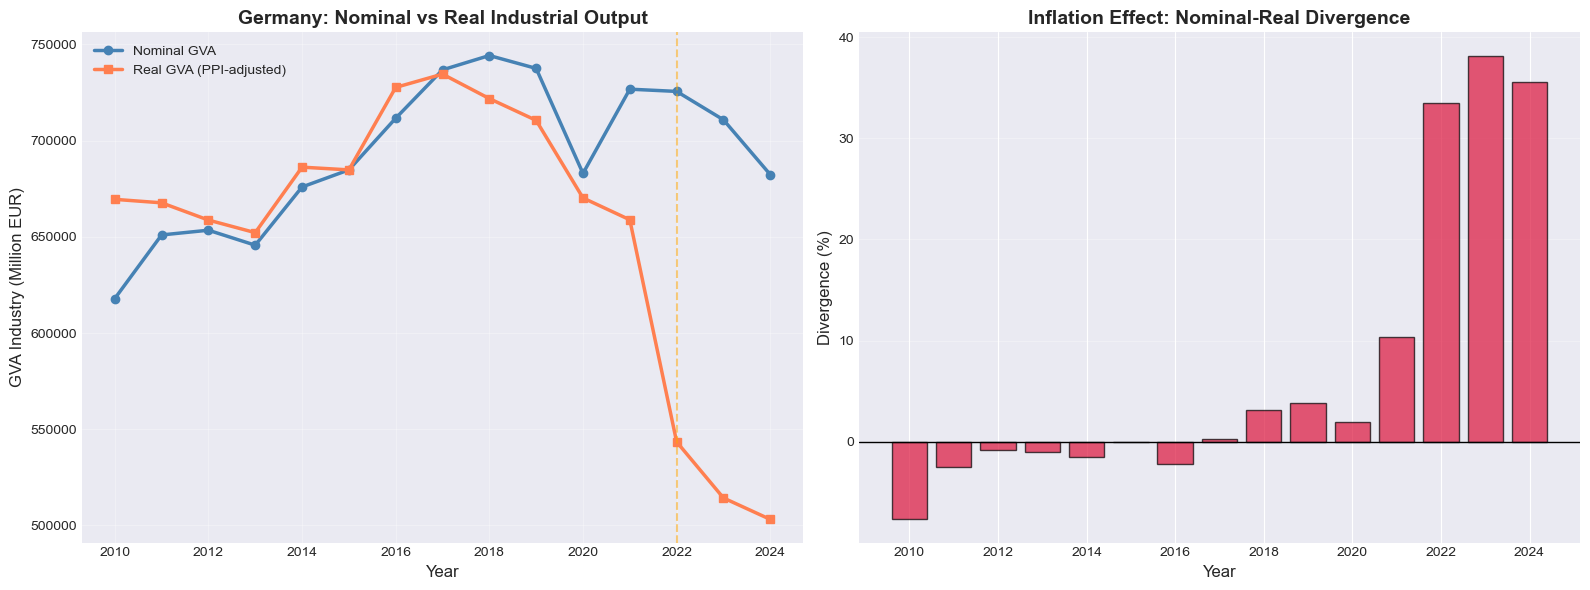


Germany EXAMPLE:
    - 2010-2019: Nominal ≈ Real (low inflation period)
    - 2022-2024: MASSIVE DIVERGENCE
      * Nominal GVA appears stable/growing
      * Real GVA shows actual decline

    CRITICAL INSIGHT:
    Without PPI adjustment, we would UNDERESTIMATE industrial decline.
    Inflation masks the true contraction in production volumes.

    This justifies using 'Real GVA' as the dependent variable in our econometric model.


In [21]:
# Load GVA data
try:
    df_gva = pd.read_csv(f'{DATA_PATH}eurostat_gva.csv')
    
    # Merge PPI with GVA
    df_combined = df_gva.merge(df_ppi[['country_code', 'year', 'ppi_index_2015']], 
                                on=['country_code', 'year'], how='left')
    
    # Calculate real GVA
    df_combined['gva_industry_real_meur'] = (df_combined['gva_industry_meur'] * 100 / 
                                              df_combined['ppi_index_2015'])
    
    # Select example country: Germany
    country_example = 'Germany'
    data = df_combined[df_combined['country'] == country_example]
    
    # Plot: Nominal vs Real
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Line plot
    axes[0].plot(data['year'], data['gva_industry_meur'], 
                marker='o', linewidth=2.5, label='Nominal GVA', color='steelblue')
    axes[0].plot(data['year'], data['gva_industry_real_meur'], 
                marker='s', linewidth=2.5, label='Real GVA (PPI-adjusted)', color='coral')
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel('GVA Industry (Million EUR)', fontsize=12)
    axes[0].set_title(f'{country_example}: Nominal vs Real Industrial Output', 
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(x=2022, color='orange', linestyle='--', alpha=0.5)
    
    # Divergence plot
    data['divergence_pct'] = ((data['gva_industry_meur'] - data['gva_industry_real_meur']) / 
                              data['gva_industry_real_meur'] * 100)
    axes[1].bar(data['year'], data['divergence_pct'], 
               color='crimson', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Year', fontsize=12)
    axes[1].set_ylabel('Divergence (%)', fontsize=12)
    axes[1].set_title('Inflation Effect: Nominal-Real Divergence', 
                     fontsize=14, fontweight='bold')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"""\n{country_example} EXAMPLE:
    - 2010-2019: Nominal ≈ Real (low inflation period)
    - 2022-2024: MASSIVE DIVERGENCE
      * Nominal GVA appears stable/growing
      * Real GVA shows actual decline
    
    CRITICAL INSIGHT:
    Without PPI adjustment, we would UNDERESTIMATE industrial decline.
    Inflation masks the true contraction in production volumes.
    
    This justifies using 'Real GVA' as the dependent variable in our econometric model.""")
    
except FileNotFoundError:
    print("Error")

## 7. Key Findings and Summary

### Main Observations:

1. **Greenflation Phenomenon:** 2022-2023 experienced unprecedented producer price inflation (20-50%)

2. **Country Heterogeneity:** 
   - Poland & Netherlands suffered highest inflation (>60% cumulative 2010-2024)
   - France relatively "better" but still ~40% inflation

3. **Temporal Pattern:**
   - Pre-2020: Stable prices near base year
   - 2020: COVID deflation
   - 2021-2023: Explosive inflation
   - 2024: Partial normalization but elevated

4. **Carbon Price Correlation:** Strong positive correlation (0.85-0.95) between carbon prices and PPI

5. **Real vs Nominal Gap:** Inflation-adjusted (real) GVA shows steeper decline than nominal figures

### Research Implications:

**For Econometric Model:**
- PPI MUST be included as a control variable
- Use real GVA (PPI-adjusted) as dependent variable
- Be aware of multicollinearity between carbon prices and PPI

**For Goal 3 (Valley of Death):**
- The 2022-2024 period has BOTH:
  * High carbon prices (€80-90/tonne)
  * High general inflation (40% PPI increase)
- This "double burden" may explain industrial stagnation
- We need to statistically separate these effects

**Methodological Note:**
- Standard economic theory: Real values remove price effects, leaving only volume changes
- Formula: **Real GVA = Nominal GVA × (100 / PPI_Index)**
- This transformation is essential for any time-series analysis spanning high-inflation periods

---

## 8. Data Export

In [ ]:
# Export summary statistics
output_path = '../../../files/'

# Summary statistics by country
summary_ppi = df_ppi.groupby('country').agg({
    'ppi_index_2015': ['mean', 'std', 'min', 'max'],
    'ppi_inflation_pct': ['mean', 'std', 'min', 'max']
}).round(2)

print("=" * 80)
print("SUMMARY STATISTICS BY COUNTRY")
print("=" * 80)
display(summary_ppi)

# Export
try:
    summary_ppi.to_csv(f'{output_path}ppi_summary_statistics.csv')
    df_ppi_change.to_csv(f'{output_path}ppi_2010_2024_change.csv', index=False)
    print(f"\n✓ Summary tables exported to {output_path}")
except:
    print(f"\n⚠ Could not export files")

## 9. Conclusions

This notebook provides comprehensive analysis of **Producer Price Index (PPI)** trends across EU-6 from 2010-2024. Key conclusions:

1. **PPI is Essential:** Without controlling for PPI, we cannot distinguish real industrial decline from inflation effects

2. **Greenflation is Real:** The 2022-2024 inflation shock is unprecedented in recent history

3. **Methodological Requirement:** All subsequent analysis must use **real (inflation-adjusted) values**

4. **Research Challenge:** Carbon prices and PPI are highly correlated, requiring careful econometric handling